In [1]:
# Load libraries
import datetime
import matplotlib.pyplot as plt
import os
import pandas as pd
import plotly.express as px
import re
import requests
import zipfile

from datetime import datetime, timedelta


In [6]:
import pandas as pd
import os

# Add your CSV file names here
csv_files = [
    'SPY_stocktwits_messages.csv',
    'tweets_remaining_09042020_16072020.csv'
]

# Loop through CSV files and read them into DataFrames
dfs = []

for csv_file in csv_files:
    file_path = os.path.join(csv_file)

    # Read CSV file with semicolon separator
    df = pd.read_csv(file_path, sep=';', on_bad_lines='skip')

    # Rename 'full_text' or 'text' column to a common name
    if 'full_text' in df.columns:
        df = df.rename(columns={'full_text': 'tweet_text'})
    elif 'text' in df.columns:
        df = df.rename(columns={'text': 'tweet_text'})

    dfs.append(df)

    print(f"Loaded: {csv_file}")

# Concatenate all DataFrames into a single DataFrame
twitter_df = pd.concat(dfs, ignore_index=True)

# Display final DataFrame
print(twitter_df.head())

# Shape
print("\nShape:", twitter_df.shape)

Loaded: SPY_stocktwits_messages.csv
Loaded: tweets_remaining_09042020_16072020.csv
              ,Sentence,Timestamp,DateTime,Sentiment  id created_at tweet_text
0  25,$SPY watching squawk box im losing brain ce... NaN        NaN        NaN
1  24,$SPY there’s no cure,1584964276000,2020/03/... NaN        NaN        NaN
2                        22,"$SPY $DJIA $AAPL $TSLA  NaN        NaN        NaN
3                         It’s only just beginning.  NaN        NaN        NaN
4  There are now two dead medical professionals b... NaN        NaN        NaN

Shape: (310786, 4)


In [7]:
# Convert timestamps to the New York timezone
twitter_df['created_at'] = pd.to_datetime(twitter_df['created_at']).dt.tz_convert('America/New_York')
twitter_df


,",Sentence,Timestamp,DateTime,Sentiment",id,created_at,tweet_text
0,"25,$SPY watching squawk box im losing brain ce...",NaN,NaT,NaN
1,"24,$SPY there’s no cure,1584964276000,2020/03/...",NaN,NaT,NaN
2,"22,""$SPY $DJIA $AAPL $TSLA",NaN,NaT,NaN
3,It’s only just beginning.,NaN,NaT,NaN
4,There are now two dead medical professionals b...,NaN,NaT,NaN
...,...,...,...,...
310781,NaN,17055.0,2020-04-10 10:38:17-04:00,@timseymour @GuyAdami Do the markets need this...
310782,NaN,17056.0,2020-04-10 10:38:07-04:00,RT @TimmerFidelity: The #SP500 as of this morn...
310783,NaN,17057.0,2020-04-10 10:37:47-04:00,Pfizer Stock Has Risen Due to COVID-19 Vaccine...
310784,NaN,17058.0,2020-04-10 10:37:42-04:00,RT @knoxridley3: Last time we traded at $SPX 2...


In [9]:
# Create a DataFrame containing only retweets
retweets_df = twitter_df[
    twitter_df['tweet_text'].fillna('').str.startswith('RT')
]

# Create a DataFrame containing tweets that are not retweets
remainder_df = twitter_df[
    ~twitter_df['tweet_text'].fillna('').str.startswith('RT')
]

# Display the DataFrames
print("## Retweets DataFrame:")
print("This DataFrame contains only retweets from the Twitter data.")
display(retweets_df)

print("\n## Remainder DataFrame:")
print("This DataFrame contains tweets that are not retweets.")
display(remainder_df)

## Retweets DataFrame:
This DataFrame contains only retweets from the Twitter data.


,",Sentence,Timestamp,DateTime,Sentiment",id,created_at,tweet_text
293965,NaN,3.0,2020-04-09 19:58:52-04:00,RT @KimbleCharting: Silver/Gold indicator crea...
293967,NaN,5.0,2020-04-09 19:57:59-04:00,RT @zipillinois: 3 Surprisingly Controversial ...
293968,NaN,6.0,2020-04-09 19:57:33-04:00,RT @Crypto____World: 🇿🇼ZIMBABWE🇿🇼\n\nCRYPTO NE...
293970,NaN,10.0,2020-04-09 19:57:08-04:00,RT @NorthmanTrader: I repeat: The Fed is reckl...
293972,NaN,13.0,2020-04-09 19:56:58-04:00,RT @TDANetwork: 📽️ #TheWatchList panel assesse...
...,...,...,...,...
310778,NaN,17052.0,2020-04-10 10:38:33-04:00,RT @TimmerFidelity: The #SP500 as of this morn...
310779,NaN,17053.0,2020-04-10 10:38:28-04:00,RT @david4potus2020: @realDonaldTrump People a...
310780,NaN,17054.0,2020-04-10 10:38:25-04:00,RT @frankmottek: Get the #business and #consum...
310782,NaN,17056.0,2020-04-10 10:38:07-04:00,RT @TimmerFidelity: The #SP500 as of this morn...



## Remainder DataFrame:
This DataFrame contains tweets that are not retweets.


,",Sentence,Timestamp,DateTime,Sentiment",id,created_at,tweet_text
0,"25,$SPY watching squawk box im losing brain ce...",NaN,NaT,NaN
1,"24,$SPY there’s no cure,1584964276000,2020/03/...",NaN,NaT,NaN
2,"22,""$SPY $DJIA $AAPL $TSLA",NaN,NaT,NaN
3,It’s only just beginning.,NaN,NaT,NaN
4,There are now two dead medical professionals b...,NaN,NaT,NaN
...,...,...,...,...
310776,NaN,17050.0,2020-04-10 10:38:47-04:00,But people still want to think the govt has te...
310777,NaN,17051.0,2020-04-10 10:38:36-04:00,"Bank of America: ""Amazon stands to emerge from..."
310781,NaN,17055.0,2020-04-10 10:38:17-04:00,@timseymour @GuyAdami Do the markets need this...
310783,NaN,17057.0,2020-04-10 10:37:47-04:00,Pfizer Stock Has Risen Due to COVID-19 Vaccine...


In [10]:
# Get weekly tweet counts
weekly_counts = twitter_df.set_index('created_at').resample('W-MON', label='left', closed='left').count()
weekly_counts = weekly_counts.rename_axis(index="Week Starting")
display(weekly_counts)


,",Sentence,Timestamp,DateTime,Sentiment",id,tweet_text
Week Starting,,,
2020-04-06 00:00:00-04:00,0,16823,16823


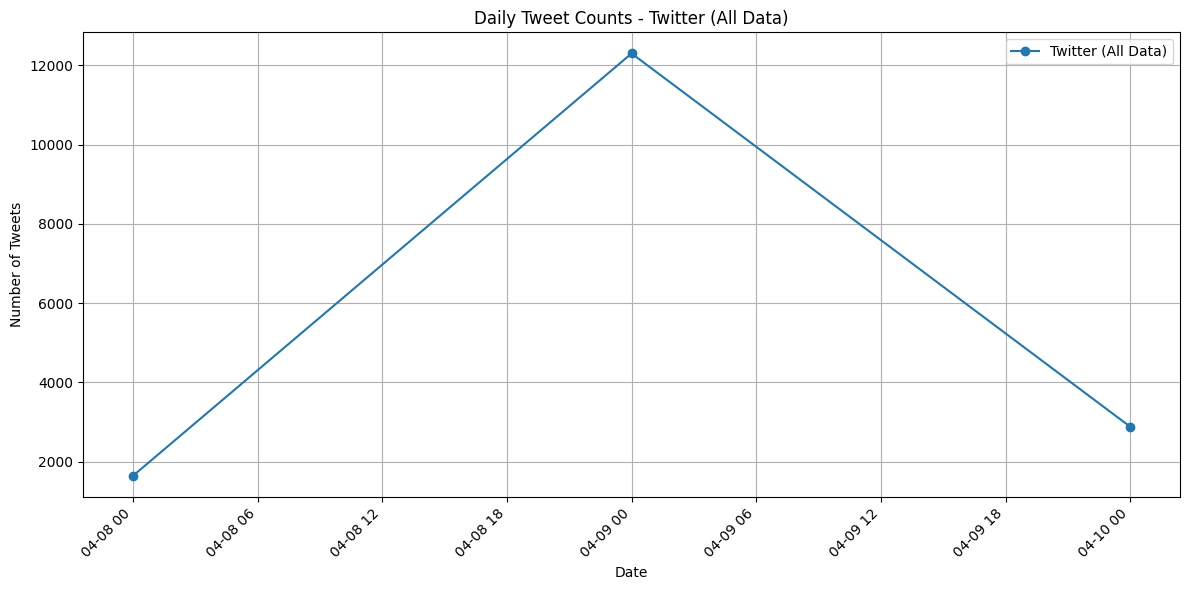

In [11]:
# GroupBy date and count
daily_tweet_counts_twitter_all = twitter_df.groupby(twitter_df['created_at'].dt.date)['tweet_text'].count()

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(daily_tweet_counts_twitter_all.index, daily_tweet_counts_twitter_all.values, label='Twitter (All Data)', marker='o')

plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title('Daily Tweet Counts - Twitter (All Data)')
plt.legend()
plt.grid(True)

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


In [12]:
# Discover stock symbols and hashtags
twitter_df['cashtags_hashtags'] = twitter_df['tweet_text'].str.findall(r'(?:\$|#)([a-zA-Z]+\.*[a-zA-Z]+)')
twitter_df.explode('cashtags_hashtags')['cashtags_hashtags'].str.lower().value_counts().sort_values(ascending=False).head(10)


cashtags_hashtags
stocks         4998
spx            4907
spy            1716
aapl           1310
es             1276
dis            1013
trading        1008
stockmarket     902
amzn            889
investing       759
Name: count, dtype: int64

In [14]:
import re

# Define a function to check for S&P 500 mentions with variations
def contains_spy(text):

    # Handle missing values safely
    text = str(text).lower()

    # Remove special characters except spaces
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    # Check for different patterns
    patterns = [
        r"\bspy\b",              # SPY
        r"\$spy\b",              # Cashtag
        r"#spy\b",               # Hashtag
        r"\bspdr\b",             # SPDR
        r"\bsp500 etf\b",        # SP500 ETF
        r"\bspy etf\b",          # SPY ETF
        r"\bsp500\b",            # SP500
        r"\bsp 500\b",           # SP 500
        r"\bsandp500\b"          # S&P500 cleaned text
    ]

    return any(re.search(pattern, text) for pattern in patterns)

# Apply the function to filter the DataFrame
filtered_twitter_df = twitter_df[
    twitter_df['tweet_text'].apply(contains_spy)
]

# Display filtered DataFrame
display(filtered_twitter_df)

# Shape
print("Filtered Shape:", filtered_twitter_df.shape)

,",Sentence,Timestamp,DateTime,Sentiment",id,created_at,tweet_text,cashtags_hashtags
293964,NaN,2.0,2020-04-09 19:58:55-04:00,#ES_F achieved Target 2780 closing above 50% #...,"[ES, Fibonacci, SPX, SPY, tradign, futures]"
293973,NaN,14.0,2020-04-09 19:56:51-04:00,$UMRX bouncing. EXTREMELY OVERSOLD #Coronaviru...,"[UMRX, Coronavirus, DECN, OPGN, CODX, HTBX, TN..."
293992,NaN,33.0,2020-04-09 19:54:47-04:00,This week's Expired Signals are now published ...,"[TGT, DG, MCD, EMB, CMCSA, AMZN, AAPL, SPY, EU..."
293993,NaN,34.0,2020-04-09 19:54:28-04:00,"$SPY $QQQ $VXX $AAPL $BA $MSFT\n\nGuys, I figu...","[SPY, QQQ, VXX, AAPL, BA, MSFT]"
293998,NaN,39.0,2020-04-09 19:54:01-04:00,$AAPL $SPY retest highs before retesting lows....,"[AAPL, SPY]"
...,...,...,...,...,...
310767,NaN,17041.0,2020-04-10 10:39:56-04:00,"$SPY $SPX Over 366,000 people have recovered f...","[SPY, SPX]"
310768,NaN,17042.0,2020-04-10 10:39:55-04:00,$TVIX can see better here\n\n$VIX $DIA $SPY $...,"[TVIX, VIX, DIA, SPY, IWM, AAPL, MSFT]"
310778,NaN,17052.0,2020-04-10 10:38:33-04:00,RT @TimmerFidelity: The #SP500 as of this morn...,[SP]
310781,NaN,17055.0,2020-04-10 10:38:17-04:00,@timseymour @GuyAdami Do the markets need this...,[]


Filtered Shape: (2276, 5)


In [15]:
''' Uncomment this code to download dataset from FigShare
# Download the SPY StockTwits dataset
url = "https://figshare.com/ndownloader/files/36172611"
response = requests.get(url)

with open("SPY_stocktwits_messages.csv", "wb") as f:
    f.write(response.content)
'''

# Read the dataset into a pandas DataFrame
stocktwits_df = pd.read_csv("SPY_stocktwits_messages.csv")
stocktwits_df

,Unnamed: 0,Sentence,Timestamp,DateTime,Sentiment
0,25,$SPY watching squawk box im losing brain cells,1.584964e+12,2020/03/23 07:50:31,NaN
1,24,$SPY there’s no cure,1.584964e+12,2020/03/23 07:51:16,Bearish
2,22,$SPY $DJIA $AAPL $TSLA \n\nIt’s only just begi...,1.584964e+12,2020/03/23 07:51:18,NaN
3,21,$SPY uh oh,1.584964e+12,2020/03/23 07:51:48,Bullish
4,20,$TVIX Im in a NY hospital with my mom. They do...,1.584964e+12,2020/03/23 07:52:11,NaN
...,...,...,...,...,...
280608,307397,More Evidence that the ‘Worst is Over’ in the ...,1.588136e+12,2020/04/29 00:47:02,Bullish
280609,307396,$SPY costs of the stimulus should be paid by C...,1.588136e+12,2020/04/29 00:47:22,NaN
280610,307395,$SPY That bear attack got stopped in its track...,1.588136e+12,2020/04/29 00:47:26,Bullish
280611,307394,$SPY GAAAARRROONNNTEEEEEDDD TO BE UP... see 28...,1.588136e+12,2020/04/29 00:47:42,Bullish


In [16]:
# Convert 'DateTime' column to DateTime objects
stocktwits_df['DateTime'] = pd.to_datetime(stocktwits_df['DateTime'])

# Filter stocktwits_df DateTime from April 9 to July 16, 2020
start_date = pd.to_datetime('2020-04-09')
end_date = pd.to_datetime('2020-07-16')

filtered_stocktwits_df = stocktwits_df[(stocktwits_df['DateTime'] >= start_date) & (stocktwits_df['DateTime'] <= end_date)].copy()
filtered_stocktwits_df


,Unnamed: 0,Sentence,Timestamp,DateTime,Sentiment
151678,168399,"$SPY I currently have $AAPL, $XOM, and $JBLU c...",1.586405e+12,2020-04-09 00:00:00,NaN
151679,168398,$SPY So besides NYC the rest of the world is b...,1.586405e+12,2020-04-09 00:00:34,Bearish
151680,168397,$SPY bulls thinking numbers are priced in beca...,1.586405e+12,2020-04-09 00:00:39,Bearish
151681,168396,$SPY plunge protection team is in full effect!,1.586405e+12,2020-04-09 00:01:03,Bullish
151682,168395,$SPY if i played futures i&#39;d go long right...,1.586405e+12,2020-04-09 00:01:37,NaN
...,...,...,...,...,...
280607,307398,$SPY,1.588136e+12,2020-04-29 00:47:00,Bullish
280608,307397,More Evidence that the ‘Worst is Over’ in the ...,1.588136e+12,2020-04-29 00:47:02,Bullish
280609,307396,$SPY costs of the stimulus should be paid by C...,1.588136e+12,2020-04-29 00:47:22,NaN
280610,307395,$SPY That bear attack got stopped in its track...,1.588136e+12,2020-04-29 00:47:26,Bullish


In [17]:
# Convert Timestamp values to pandas DateTime object
filtered_stocktwits_df.loc[:, 'DateTime_from_Timestamp'] = pd.to_datetime(filtered_stocktwits_df['Timestamp'], unit='ms')
filtered_stocktwits_df


,Unnamed: 0,Sentence,Timestamp,DateTime,Sentiment,DateTime_from_Timestamp
151678,168399,"$SPY I currently have $AAPL, $XOM, and $JBLU c...",1.586405e+12,2020-04-09 00:00:00,NaN,2020-04-09 04:00:00
151679,168398,$SPY So besides NYC the rest of the world is b...,1.586405e+12,2020-04-09 00:00:34,Bearish,2020-04-09 04:00:34
151680,168397,$SPY bulls thinking numbers are priced in beca...,1.586405e+12,2020-04-09 00:00:39,Bearish,2020-04-09 04:00:39
151681,168396,$SPY plunge protection team is in full effect!,1.586405e+12,2020-04-09 00:01:03,Bullish,2020-04-09 04:01:03
151682,168395,$SPY if i played futures i&#39;d go long right...,1.586405e+12,2020-04-09 00:01:37,NaN,2020-04-09 04:01:37
...,...,...,...,...,...,...
280607,307398,$SPY,1.588136e+12,2020-04-29 00:47:00,Bullish,2020-04-29 04:47:00
280608,307397,More Evidence that the ‘Worst is Over’ in the ...,1.588136e+12,2020-04-29 00:47:02,Bullish,2020-04-29 04:47:02
280609,307396,$SPY costs of the stimulus should be paid by C...,1.588136e+12,2020-04-29 00:47:22,NaN,2020-04-29 04:47:22
280610,307395,$SPY That bear attack got stopped in its track...,1.588136e+12,2020-04-29 00:47:26,Bullish,2020-04-29 04:47:26


In [18]:
# Convert and localize Timestamp values to NY timezone
filtered_stocktwits_df['DateTime_from_Timestamp'] = pd.to_datetime(filtered_stocktwits_df['Timestamp'], unit='ms', utc=True).dt.tz_convert('America/New_York')
filtered_stocktwits_df


,Unnamed: 0,Sentence,Timestamp,DateTime,Sentiment,DateTime_from_Timestamp
151678,168399,"$SPY I currently have $AAPL, $XOM, and $JBLU c...",1.586405e+12,2020-04-09 00:00:00,NaN,2020-04-09 00:00:00-04:00
151679,168398,$SPY So besides NYC the rest of the world is b...,1.586405e+12,2020-04-09 00:00:34,Bearish,2020-04-09 00:00:34-04:00
151680,168397,$SPY bulls thinking numbers are priced in beca...,1.586405e+12,2020-04-09 00:00:39,Bearish,2020-04-09 00:00:39-04:00
151681,168396,$SPY plunge protection team is in full effect!,1.586405e+12,2020-04-09 00:01:03,Bullish,2020-04-09 00:01:03-04:00
151682,168395,$SPY if i played futures i&#39;d go long right...,1.586405e+12,2020-04-09 00:01:37,NaN,2020-04-09 00:01:37-04:00
...,...,...,...,...,...,...
280607,307398,$SPY,1.588136e+12,2020-04-29 00:47:00,Bullish,2020-04-29 00:47:00-04:00
280608,307397,More Evidence that the ‘Worst is Over’ in the ...,1.588136e+12,2020-04-29 00:47:02,Bullish,2020-04-29 00:47:02-04:00
280609,307396,$SPY costs of the stimulus should be paid by C...,1.588136e+12,2020-04-29 00:47:22,NaN,2020-04-29 00:47:22-04:00
280610,307395,$SPY That bear attack got stopped in its track...,1.588136e+12,2020-04-29 00:47:26,Bullish,2020-04-29 00:47:26-04:00


In [19]:
# Replace 'NaN' with 'Neutral' in the 'Sentiment' column before grouping, using .loc
filtered_stocktwits_df.loc[filtered_stocktwits_df['Sentiment'].isnull(), 'Sentiment'] = 'Neutral'

# Group the data by date and sentiment, then count occurrences
sentiment_counts = filtered_stocktwits_df.groupby([filtered_stocktwits_df['DateTime_from_Timestamp'].dt.date, 'Sentiment'])['Sentiment'].count().unstack(fill_value=0)
sentiment_counts = sentiment_counts[['Bearish', 'Neutral', 'Bullish']] # reorder columns in specific order

# Create the interactive bar plot using Plotly
fig = px.bar(sentiment_counts, x=sentiment_counts.index, y=sentiment_counts.columns,
             labels={'x': 'Date', 'y': 'Count'},
             title='Daily Sentiment Counts - StockTwits (Bearish, Neutral, Bullish)',
             color_discrete_map={'Bearish': 'red', 'Neutral': 'grey', 'Bullish': 'green'})

# Customize the layout for better readability and display the plot
fig.update_layout(barmode='group', xaxis_tickangle=-45)
fig.show()


In [20]:
# Discovering stock symbols in StockTwits data
filtered_stocktwits_df['tickers'] = filtered_stocktwits_df['Sentence'].str.findall('\$[a-zA-Z]+\.*[a-zA-Z]+')
filtered_stocktwits_df.explode(['tickers'])['tickers'].value_counts().sort_values(ascending=False).head(10)


<>:2: SyntaxWarning:

invalid escape sequence '\$'

<>:2: SyntaxWarning:

invalid escape sequence '\$'

C:\Users\DELL\AppData\Local\Temp\ipykernel_39456\3304748835.py:2: SyntaxWarning:

invalid escape sequence '\$'



tickers
$SPY     126674
$QQQ       4654
$spy       2742
$SPX       2425
$AAPL      2299
$DJIA      1980
$ES        1835
$TSLA      1624
$DIA       1469
$USO       1370
Name: count, dtype: int64

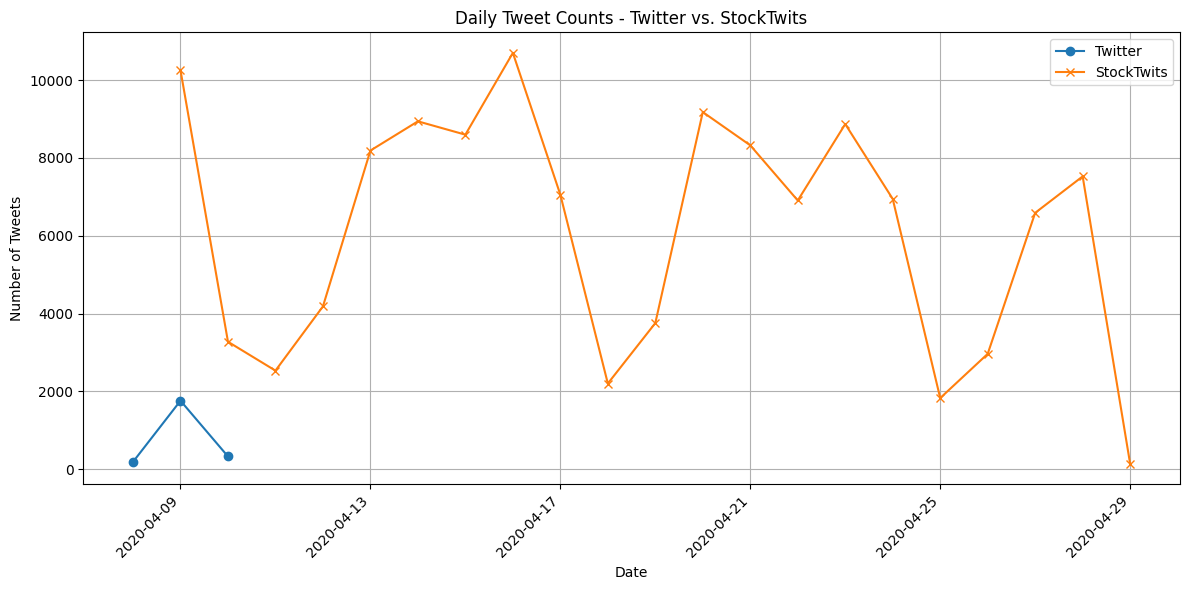

In [21]:
# Group Twitter data by date and count tweets
daily_tweet_counts_twitter = filtered_twitter_df.groupby(filtered_twitter_df['created_at'].dt.date)['tweet_text'].count()

# Group StockTwits data by date and count messages
daily_tweet_counts_stocktwits = filtered_stocktwits_df.groupby(filtered_stocktwits_df['DateTime_from_Timestamp'].dt.date)['Sentence'].count()

# # Create a figure and plot Twitter and StockTwits data
plt.figure(figsize=(12, 6))
plt.plot(daily_tweet_counts_twitter.index, daily_tweet_counts_twitter.values, label='Twitter', marker='o')
plt.plot(daily_tweet_counts_stocktwits.index, daily_tweet_counts_stocktwits.values, label='StockTwits', marker='x')

# Customize the plot
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title('Daily Tweet Counts - Twitter vs. StockTwits')
plt.legend()
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent overlapping labels and display the plot
plt.tight_layout()
plt.show()
